# LEMMATIZATION TASKS IN NLP

Required Libraries
-

In [5]:
import nltk
import spacy
from nltk.stem import WordNetLemmatizer, PorterStemmer
from nltk.corpus import stopwords, wordnet
from nltk import pos_tag, word_tokenize
from collections import Counter
import pandas as pd
import matplotlib.pyplot as plt

In [7]:
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('averaged_perceptron_tagger')
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\fsher\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\fsher\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     C:\Users\fsher\AppData\Roaming\nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\fsher\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\fsher\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [11]:
nlp = spacy.load("en_core_web_sm")

Function to map NLTK POS tags to WordNet POS
-

In [17]:
def get_wordnet_pos(tag):
    if tag.startswith('J'):
        return wordnet.ADJ
    elif tag.startswith('V'):
        return wordnet.VERB
    elif tag.startswith('N'):
        return wordnet.NOUN
    elif tag.startswith('R'):
        return wordnet.ADV
    else:
        return wordnet.NOUN

In [19]:
lemmatizer = WordNetLemmatizer()
stemmer = PorterStemmer()

Task No. 1
-

In [26]:
import nltk
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     C:\Users\fsher\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping taggers\averaged_perceptron_tagger_eng.zip.


True

In [28]:
words = ["studies", "am", "went", "feet", "flying", "cars", "mice", "better", "ate"]

for word, tag in pos_tag(words):
    lemma = lemmatizer.lemmatize(word, get_wordnet_pos(tag))
    print(f"{word} ({tag}) → {lemma}")

studies (NNS) → study
am (VBP) → be
went (VBD) → go
feet (NNS) → foot
flying (VBG) → fly
cars (NNS) → car
mice (RB) → mice
better (RB) → well
ate (VB) → eat


Task No. 2
-

In [32]:
def lemmatize_sentence_list(sent_list):
    pairs = []
    for sent in sent_list:
        doc = nlp(sent)
        lemmatized = " ".join([token.lemma_ for token in doc])
        pairs.append((sent, lemmatized))
    return pairs

In [34]:
sentences = ["The students are studying hard.", "Dogs are barking loudly."]
for orig, lemma in lemmatize_sentence_list(sentences):
    print(f"Original: {orig}\nLemmatized: {lemma}\n")

Original: The students are studying hard.
Lemmatized: the student be study hard .

Original: Dogs are barking loudly.
Lemmatized: dog be bark loudly .



Task No. 3
-

In [37]:
words2 = ["studies", "better", "flying", "easily", "running"]
print(f"{'Word':<10}{'Stemmed':<15}{'Lemmatized'}")
for w in words2:
    print(f"{w:<10}{stemmer.stem(w):<15}{lemmatizer.lemmatize(w, 'v')}")

Word      Stemmed        Lemmatized
studies   studi          study
better    better         better
flying    fli            fly
easily    easili         easily
running   run            run


In [39]:
print("\nDifference: Stemming just chops endings, Lemmatization uses linguistic rules for correct base forms.")


Difference: Stemming just chops endings, Lemmatization uses linguistic rules for correct base forms.


Task No. 4
-

In [42]:
para = """My university name is THE UNIVERSITY OF FAISALABAD and it is located in Faisalabad. Students from all over the country come here to study.
The environment is peaceful, and the teachers are very supportive."""

lemmas = [token.lemma_.lower() for token in nlp(para) if token.is_alpha]
print("Total Words:", len(lemmas))
print("Unique Lemmas:", len(set(lemmas)))
print("Lemmas Sample:", lemmas[:15])

Total Words: 34
Unique Lemmas: 25
Lemmas Sample: ['my', 'university', 'name', 'be', 'the', 'university', 'of', 'faisalabad', 'and', 'it', 'be', 'locate', 'in', 'faisalabad', 'student']


Task No. 5
-

In [45]:
for word, tag in pos_tag(word_tokenize("Running dogs quickly ate bones")):
    lemma = lemmatizer.lemmatize(word, get_wordnet_pos(tag))
    print(f"{word} ({tag}) → {lemma}")

Running (VBG) → Running
dogs (NNS) → dog
quickly (RB) → quickly
ate (VBP) → eat
bones (NNS) → bone


Task No. 6
-

In [48]:
stop_words = set(stopwords.words('english'))
text = "The students are studying hard for their final examinations and they want good grades."
tokens = [word for word in word_tokenize(text.lower()) if word.isalpha() and word not in stop_words]
lemmas = [lemmatizer.lemmatize(w) for w in tokens]
print("Clean Tokens:", lemmas)
print("Remaining Count:", len(lemmas))

Clean Tokens: ['student', 'studying', 'hard', 'final', 'examination', 'want', 'good', 'grade']
Remaining Count: 8


Task No. 7
-

In [51]:
sentence = "Dogs are chasing the cats who were running through the gardens."
spacy_lemmas = [token.lemma_ for token in nlp(sentence)]
nltk_lemmas = [lemmatizer.lemmatize(w, get_wordnet_pos(t)) for w, t in pos_tag(word_tokenize(sentence))]

In [53]:
print("spaCy Lemmas:", spacy_lemmas)
print("NLTK Lemmas:", nltk_lemmas)

spaCy Lemmas: ['dog', 'be', 'chase', 'the', 'cat', 'who', 'be', 'run', 'through', 'the', 'garden', '.']
NLTK Lemmas: ['Dogs', 'be', 'chase', 'the', 'cat', 'who', 'be', 'run', 'through', 'the', 'garden', '.']


Task No. 8
-

In [1]:
def clean_text(text):
    doc = nlp(text.lower())
    return [token.lemma_ for token in doc if token.is_alpha and not token.is_stop]

In [58]:
text = "Running runners run faster when the weather is better!"
print("Cleaned Text:", clean_text(text))

Cleaned Text: ['run', 'runner', 'run', 'fast', 'weather', 'well']


Task No. 9
-

In [61]:
para2 = """Students love learning when teachers make classes interactive and engaging. 
Learning is easier when examples are practical and fun."""
lemmas = [token.lemma_.lower() for token in nlp(para2) if token.is_alpha]
freq = Counter(lemmas)
print("Top 5 Lemmas:", freq.most_common(5))

Top 5 Lemmas: [('when', 2), ('and', 2), ('be', 2), ('student', 1), ('love', 1)]


Task No. 10
-

In [64]:
present = "Students write their assignments and submit them to the teacher."
past = "Students wrote their assignments and submitted them to the teacher."

In [66]:
present_lemmas = [t.lemma_ for t in nlp(present)]
past_lemmas = [t.lemma_ for t in nlp(past)]
print("Present Lemmas:", present_lemmas)
print("Past Lemmas:", past_lemmas)
print("Difference: Verbs are reduced to the same lemma ('write', 'submit').")

Present Lemmas: ['student', 'write', 'their', 'assignment', 'and', 'submit', 'they', 'to', 'the', 'teacher', '.']
Past Lemmas: ['student', 'write', 'their', 'assignment', 'and', 'submit', 'they', 'to', 'the', 'teacher', '.']
Difference: Verbs are reduced to the same lemma ('write', 'submit').


Task No. 11
-

In [69]:
data = pd.DataFrame({"Review": ["The product was amazing!", "I loved the design.", "The delivery was late."]})
data["Clean_Review"] = data["Review"].apply(lambda x: " ".join(clean_text(x)))
print(data)

                     Review     Clean_Review
0  The product was amazing!  product amazing
1       I loved the design.      love design
2    The delivery was late.    delivery late


Task No. 12
-

In [72]:
class MyLemmatizer:
    def __init__(self):
        self.nlp = spacy.load("en_core_web_sm")

    def lemmatize(self, text):
        return [token.lemma_.lower() for token in self.nlp(text) if token.is_alpha]

    def compare(self, s1, s2):
        lem1 = set(self.lemmatize(s1))
        lem2 = set(self.lemmatize(s2))
        overlap = len(lem1 & lem2) / len(lem1 | lem2) * 100
        print(f"Lemma Overlap: {overlap:.2f}%")

In [74]:
my_lem = MyLemmatizer()
my_lem.compare("The students are studying hard", "Students study very hard for exams")

Lemma Overlap: 37.50%


Bonus Task
-

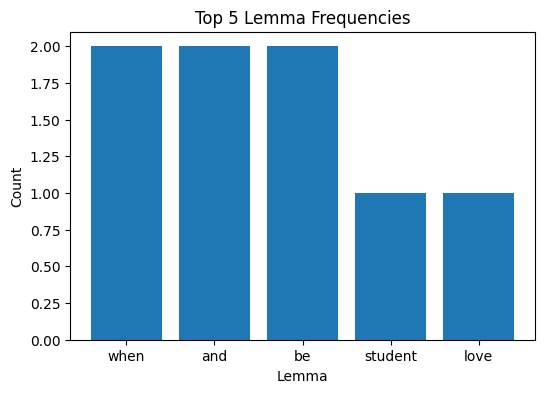

In [77]:
plt.figure(figsize=(6,4))
plt.bar(*zip(*freq.most_common(5)))
plt.title("Top 5 Lemma Frequencies")
plt.xlabel("Lemma")
plt.ylabel("Count")
plt.show()